In [1]:
%cd ../..
%env NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="

/home/jj/Research/ConceptualSensitivityRegularization
env: NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from csr.module.utils.notebookutils import NeptuneViewer
pd.options.display.float_format = '{:,.4f}'.format

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# 1. Get DataFrame from Neptune project

In [3]:
project_name = '240406CelebaCollar'
df = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', project_name).query('dataset == "celeba_collar"')
print('-'*20)
print(len(df))

cktp_list = df.query('module_name == "CGR"')['g_ckpt_path'].unique()
for key, module_name in zip(['celeba_collar_concepts_v2_convnext_t_svm', 'celeba_collar_concepts_v2_convnext_t_signal', 'TEM-619'], ['RRC-SVM', 'RRC-Signal', 'CGR_619']):
    try:
        ckpt = [i for i in cktp_list if key in i][0]
    except:
        continue
    idx = df.query('g_ckpt_path == @ckpt').index
    df.loc[idx, 'module_name'] = module_name


[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/240406CelebaCollar/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/240406CelebaCollar/metadata
--------------------
576


In [4]:
df['module_name'].value_counts()

module_name
GDRO          192
CGR           144
ERM            96
CGR_619        48
RRC-SVM        48
RRC-Signal     48
Name: count, dtype: int64

In [5]:
import os

df_dict = {}
dataset = 'CelebaCollar'
module_list = list(df['module_name'].value_counts().index)
for module_name in module_list:
    df_query = df.query('model == "convnext_t" and module_name == @module_name')

    ban_list = ['lr_history', 'data_seed', 'model_path', 'lr_history1', 'data_dir', 'epoch', 'max_epochs']
    var_list = (df_query.nunique() >= 2) & (df_query.nunique() <= 20)
    var_list = [i for i in df.columns[var_list] if 'acc' not in i and i not in ban_list]

    print(module_name, var_list)

    df_query = df_query.sort_values(by=var_list)
    os.makedirs(f'./notebooks/results_viewer/exps/{dataset}/', exist_ok=True)
    df_query.set_index(var_list).to_csv(f'./notebooks/results_viewer/exps/{dataset}/{module_name}.csv')
    df_dict[module_name] = df_query.set_index(var_list)

    for var in var_list:
        print(var, df_query[var].unique())
    print()


GDRO ['eta', 'learning_rate', 'minor_ratio']
eta [1.e-02 3.e-02 1.e-01 3.e-01 1.e+00 3.e+00 1.e+01 3.e+01]
learning_rate [0.0001 0.0003 0.001  0.003 ]
minor_ratio [0.   0.05]

CGR ['g_ckpt_path', 'g_model', 'lamb_cs', 'minor_ratio']
g_ckpt_path ['/home/jj/Research/ConceptualSensitivityRegularization/.neptune/temp/TEM-610/checkpoints/last.ckpt'
 '/home/jj/Research/ConceptualSensitivityRegularization/data/cavs/celeba_collar_concepts_convnext_t_svm.pt'
 '/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/data/cavs/celeba_collar_concepts_convnext_t_signal.pt']
g_model ['three_layer' 'linear']
lamb_cs [1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06]
minor_ratio [0.   0.05]

ERM ['batch_size_train', 'learning_rate', 'minor_ratio', 'set_last_layer']
batch_size_train [16 32]
learning_rate [0.0001 0.0003 0.001  0.003 ]
minor_ratio [0.   0.05]
set_last_layer ['linear' 'three_layer']

CGR_619 ['lamb_cs', 'minor_ratio']
lamb_cs [1.e-06 1.e-04 1.e-02 1.e+00 1.e+02 1.e+04 1.e+0

In [6]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]

def sort_and_query(df, sort_by, query):
    df_temp = df.sort_values(by=sort_by)
    df_temp = df_temp.query(query)
    return df_temp

def get_wga(df, module_name):
    df_query = df.query('model == "convnext_t" and module_name == @module_name')

    ban_list = ['lr_history', 'data_seed', 'model_path']
    var_list = (df_query.nunique() >= 2) & (df_query.nunique() <= 10)
    var_list = [i for i in df.columns[var_list] if 'acc' not in i and i not in ban_list]

    expected_length = 1
    print(var_list)
    for i in var_list:
        print(i, df_query[i].nunique(), end=', ')
        expected_length *= df_query[i].nunique()
    print()
    print(f'Expected {expected_length}, got {len(df_query)}')

    idx = get_best_index(df_query, var_list, 'valid_valid_best_worst_acc')

    best_mean = get_mean_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    best_std = get_std_with_given_index(df_query, var_list, 'test_worst_acc', idx)
    test_acc_mean = get_mean_with_given_index(df_query, var_list, 'test_acc', idx)
    test_acc_std = get_std_with_given_index(df_query, var_list, 'test_acc', idx)

    return idx, best_mean, best_std, test_acc_mean, test_acc_std

['batch_size_train', 'learning_rate', 'minor_ratio', 'set_last_layer']
batch_size_train 2, learning_rate 4, minor_ratio 2, set_last_layer 2, 
Expected 32, got 96
['lamb_cs', 'minor_ratio']
lamb_cs 8, minor_ratio 2, 
Expected 16, got 48
['lamb_cs', 'minor_ratio']
lamb_cs 8, minor_ratio 2, 
Expected 16, got 48
['lamb_cs', 'minor_ratio']
lamb_cs 8, minor_ratio 2, 
Expected 16, got 48
['eta', 'learning_rate', 'minor_ratio']
eta 8, learning_rate 4, minor_ratio 2, 
Expected 64, got 192


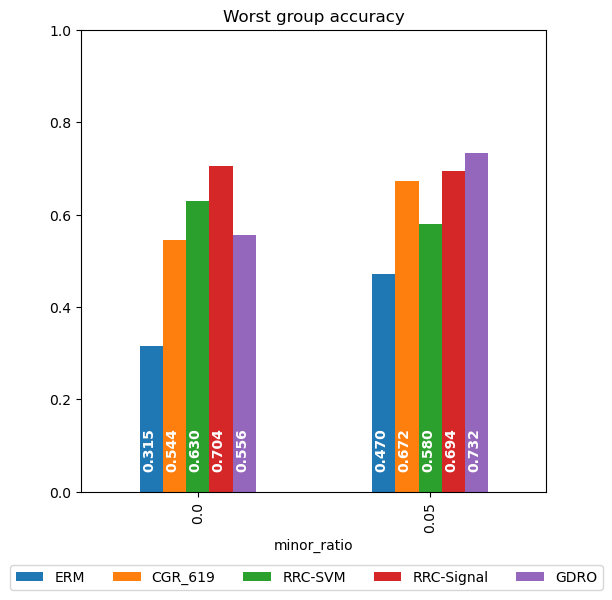

In [7]:
module_list = ['ERM', 'CGR_619', 'RRC-SVM', 'RRC-Signal', 'GDRO']

# get best_mean std and plot
best_idx_list = []
best_mean_list = []
best_std_list = []
test_mean_list = []
test_std_list = [] 
for module_name in module_list:
    best_idx, best_mean, best_std, test_acc_mean, test_acc_std = get_wga(df, module_name)
    best_idx_list.append(best_idx)
    best_mean_list.append(best_mean)
    best_std_list.append(best_std)
    test_mean_list.append(test_acc_mean)
    test_std_list.append(test_acc_std)

fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat(best_mean_list, axis=1)
best_model_mean.columns = module_list

# plot best model mean
bars = best_model_mean.plot(kind='bar', yerr=pd.concat(best_std_list, axis=1), ax=ax, capsize=5, legend=False, ylim=(0, 1))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)
ax.set_title('Worst group accuracy')

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.24 + j * (0.5/len(module_list)) , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)
plt.savefig('notebooks/results_viewer/figure/celeba_collar_v2_wga.png', bbox_inches='tight')
plt.show()

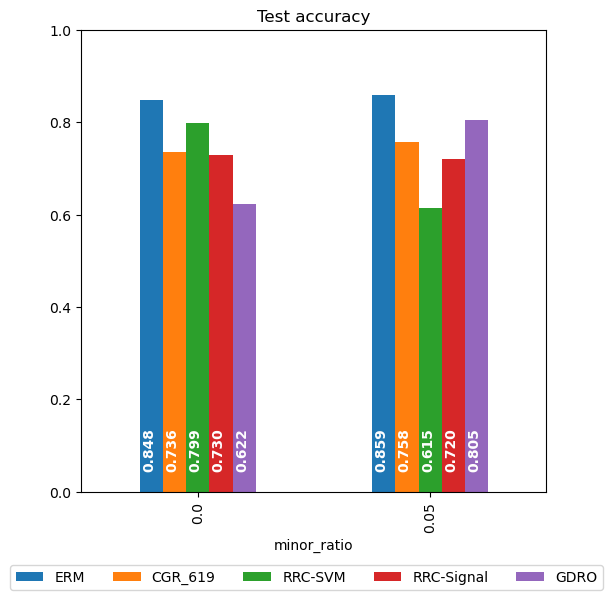

In [8]:
fig, ax = plt.subplots(1,1, figsize=(6,6))

test_mean = pd.concat(test_mean_list, axis=1)
test_mean.columns = module_list

# plot best model mean
bars = test_mean.plot(kind='bar', yerr=pd.concat(test_std_list, axis=1), ax=ax, capsize=5, legend=False, ylim=(0, 1))
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=5)
ax.set_title('Test accuracy')

for i, vs in enumerate(test_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.24 + j * (0.5/len(module_list)) , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)
plt.savefig('notebooks/results_viewer/figure/celeba_collar_v2_ta.png', bbox_inches='tight')
plt.show()



In [9]:
df.dataset.value_counts()

dataset
celeba_collar    528
catdog            48
Name: count, dtype: int64

In [10]:
def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]


df_temp = df.query('module_name == "CSR"')
var_list = ['minor_ratio', 'lamb_cs']
metric = 'valid_valid_best_worst_acc'
df_mean = df_temp.groupby(var_list)[metric].mean().sort_index()
idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()

In [11]:
df_mean

Series([], Name: valid_valid_best_worst_acc, dtype: float64)

In [12]:
idx

Series([], Name: valid_valid_best_worst_acc, dtype: int64)

In [13]:
df.query('module_name == "CSR" and minor_ratio == 0 and lamb_cs == 0.0001')[['id', 'test_worst_acc', 'valid_valid_best_epoch']]

,id,test_worst_acc,valid_valid_best_epoch


In [14]:
df.query('module_name == "CSR" and minor_ratio == 0.05 and lamb_cs == 0.0001')[['id', 'test_worst_acc', 'valid_valid_best_epoch']]

,id,test_worst_acc,valid_valid_best_epoch
